# Interoperability of EC and ERA5-Land Data Analysis

This python notebook shows how metadata and semantics of the eddy covariance (EC) data stored on https://tidbrepo.usm.my can be retrieved and used in conjuction with another dataset, ERA5.

The persistent identification (PID) of the database is https://tidbrepo.usm.my/pid/0ce49c88-33dd-4b3c-9506-4c98f692e7b7.

## EC Data Retrieval


Load Modules for DBRepo. Modules needed:
1. `dbrepo.RestClient`
2. `urllib3` (note to suppress warnings, which might pop up)

Load modules for dataframes:
1. `pandas`


In [1]:

from dbrepo.RestClient import RestClient
import urllib3
import pandas as pd

urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)


### TIDBRepo Access Settings

The URL (endpoint) to the database is public.

In [2]:

client = RestClient(
    endpoint = "https://tidbrepo.usm.my",
    secure = False
)


### TIDBRepo Database and Table Identification

The database and table IDs need to be obtained from the repository. Determine the database ID by calling the `get_databases` function.

List all databases that are public.

In [3]:

db = client.get_databases()

for d in db:
    print({
        "Name": d.name,
        "Database ID": d.id,
        "Public": d.is_public
    })


{'Name': 'LST Analysis', 'Database ID': '66bc782d-964a-4f2c-b182-bf28d0cd669d', 'Public': True}
{'Name': 'mkh_eddy_covariance', 'Database ID': 'f202bc5d-738c-41d7-b40d-a6fcd047a0ca', 'Public': True}
{'Name': 'analysis_ch4_gosat_tropomi_heng_2026', 'Database ID': 'bdb03710-4c1c-46b2-9b24-122d6bf794be', 'Public': True}
{'Name': 'Sungai Dua, Universiti Sains Malaysia, Water Quality', 'Database ID': '7f048d8c-35d4-4deb-9252-d1a04937594b', 'Public': True}
{'Name': 'Deep Learning Bias Correction in WRF', 'Database ID': 'adc8337c-718e-4653-aaaf-92d4bdf23c1c', 'Public': True}
{'Name': 'emission_factor_malaysia', 'Database ID': '8cb5b734-7d57-4ca5-81a6-4d1de7acee88', 'Public': True}
{'Name': 'MKH_water_temperature', 'Database ID': 'eff62402-14d8-4f8b-884b-ae6735875bd6', 'Public': True}


### Database ID

The name of the database.

In [4]:

target_name = "mkh_eddy_covariance"


In [5]:

DB_ID = next(d.id for d in db if d.name == target_name)

print(DB_ID)


f202bc5d-738c-41d7-b40d-a6fcd047a0ca


In [6]:

tb = client.get_tables(database_id = DB_ID)


Print list of tables in the database.

In [7]:

print(tb)


[TableBrief(id='2c9b0979-4c9e-4c77-a550-0aeea9eff80d', database_id='f202bc5d-738c-41d7-b40d-a6fcd047a0ca', name='Eddy Covariance', description='The biomet and full output of the eddy covariance data from MKH.', internal_name='eddy_covariance', is_versioned=True, is_public=True, is_schema_public=True, owned_by='yusriy')]



### Table ID


The identification alphanumeric number of the table.

In [9]:

TB_ID = tb[0].id
print(TB_ID)


2c9b0979-4c9e-4c77-a550-0aeea9eff80d



### Obtain the coordinates of the station from the Method section of the description.


This cell shows how the coordinates can be extracted from the methods section of the metadata. We start with finding the identifier description of type METHODS.

In [11]:

db = client.get_database(DB_ID)

methods_text = None

for ident in db.identifiers:
    for desc in ident.descriptions:
        if str(desc.type).endswith("METHODS"):
            methods_text = desc.description
            break
    if methods_text:
        break

print(methods_text)


Raw eddy covariance data were collected at Muka Head (latitude 5.46694994, longitude 100.1999969) using a Young 81000 sonic anemometer and a LI-COR LI-7500A open-path gas analyzer. Acquisition frequency was 10 Hz, and processing was performed at 30-minute averaging intervals in EddyPro (software version 7). Configuration included coordinate rotation (rot_meth=1), time-lag handling (tlag_meth=2), WPL correction enabled (wpl_meth=1), flow-distortion correction enabled, qc_meth=1, and filtering/test settings for absolute limits, amplitude resolution, dropout, skewness/kurtosis, and spike-related checks. Detrending was set to detrend_meth=0. Missing/error label in project settings is -9999.0, but removed during DBRepo upload. Outputs were generated in rich format with metadata export enabled.




### Extract the coordinates using `regex`.


Use coordinates obtained from the DBRepo Method section

In [12]:

import re

pattern = r'latitude\s+(-?\d+(?:\.\d+)?)\s*,\s*longitude\s+(-?\d+(?:\.\d+)?)'
m = re.search(pattern, methods_text, flags=re.IGNORECASE)

if m:
    lat = float(m.group(1))
    lon = float(m.group(2))
    print("Latitude:", lat)
    print("Longitude:", lon)
else:
    print("Coordinates not found")


Latitude: 5.46694994
Longitude: 100.1999969


In [13]:

site_lat = lat      
site_lon = lon


### Semantics Retrieval

The `get_table()` function fetches all metadata (concept, ontology, and unit) and description info of the database and table.

In [14]:

table = client.get_table(DB_ID, TB_ID)


### Build semantic table

In [15]:

rows = []
for col in table.columns:
    rows.append({
        "ec_name": col.name,
        "ec_var": col.internal_name,
        "ec_description": col.description,
        "ec_concept_uri": col.concept.uri if col.concept else None,
        "ec_unit_uri": col.unit.uri if col.unit else None,
    })

ec_semantics = pd.DataFrame(rows)


### Show the Semantics

In [16]:

print(ec_semantics.head())
print(ec_semantics.shape)


        ec_name        ec_var  \
0     timestamp     timestamp   
1           DOY           doy   
2       daytime       daytime   
3  file_records  file_records   
4  used_records  used_records   

                                      ec_description  \
0  End-of-interval timestamp for each processed r...   
1          Day-of-year index derived from timestamp.   
2            Day/night indicator used in processing.   
3  Number of raw records available in the averagi...   
4  Number of records used after quality screening...   

                           ec_concept_uri  \
0  http://www.wikidata.org/entity/Q186408   
1         http://dbpedia.org/ontology/day   
2         http://dbpedia.org/ontology/day   
3      http://dbpedia.org/ontology/Record   
4      http://dbpedia.org/ontology/Record   

                                         ec_unit_uri  
0  http://www.ontology-of-units-of-measure.org/re...  
1  http://www.ontology-of-units-of-measure.org/re...  
2  http://www.ontology-of-un

### Data Retrieval

In [17]:

KEY_TS = pd.Timestamp("2026-03-28 00:00:00")

# Retrive the data
df_ec = pd.DataFrame(
    client.get_table_data(database_id = DB_ID, 
                          table_id = TB_ID, 
                          timestamp = KEY_TS)
)


### Show the data

In [18]:

print(df_ec.shape)
df_ec.head()


(3399, 128)


,timestamp,doy,daytime,file_records,used_records,tau,qc_tau,h,qc_h,le,...,loggertemp,vin_1_1_1,ppfd_1_1_1,p_rain_1_1_1,rg_1_1_1,rg_1_1_1_1,rh_1_1_1,rn_1_1_1,ta_1_1_1,ts_1_1_1
0,2026-01-01 00:30:00.0,1.0208,0,18000,18000,-0.004966,1,2.48287,1,23.6376,...,29.20,11.8805,-0.0377,0.0,0.0996,NaN,86.2935,-46.9712,301.109,294.082
1,2026-01-01 01:00:00.0,1.0416,0,18000,18000,-0.003716,1,1.97753,1,17.1267,...,29.03,11.8779,-0.0411,0.0,0.0885,NaN,86.9287,-47.7717,300.999,294.062
2,2026-01-01 01:30:00.0,1.0624,0,18000,18000,-0.003563,1,2.08391,1,19.3397,...,28.90,11.8790,-0.1131,0.0,0.1046,NaN,86.4817,-48.7858,301.047,294.042
3,2026-01-01 02:00:00.0,1.0833,0,18000,18000,-0.002096,1,1.50592,1,15.0563,...,28.90,11.8801,0.0308,0.0,0.1101,NaN,86.3863,-48.1774,300.977,294.023
4,2026-01-01 02:30:00.0,1.1041,0,18000,18000,-0.001594,1,1.25656,1,10.7026,...,28.90,11.8793,0.0600,0.0,0.1138,NaN,86.6310,-49.4648,300.945,293.990


## ERA5-Land

### Data Download

Data needs to be downloaded from the ERA5-Land website (https://cds.climate.copernicus.eu/datasets/reanalysis-era5-land?tab=download). After selecting the parameters interested (and logging in), I copied the API request code. You would need your own API key from Copernicus.

In [ ]:

import cdsapi


In [ ]:

client = cdsapi.Client(
    url = "https://cds.climate.copernicus.eu/api",
    key = "YOUR_API_KEY"
)


#### ERA5 Download

In [ ]:

dataset = "reanalysis-era5-single-levels"

request = {
    "product_type": ["reanalysis"],
    "variable": [
        "2m_temperature",
        "surface_latent_heat_flux",
        "surface_sensible_heat_flux"
    ],
    "year": ["2026"],
    "month": ["02"],
    "day": [
        "01", "02", "03",
        "04", "05", "06",
        "07", "08", "09",
        "10", "11", "12",
        "13", "14", "15",
        "16", "17", "18",
        "19", "20", "21",
        "22", "23", "24",
        "25", "26", "27",
        "28"
    ],
    "time": [
        "00:00", "01:00", "02:00",
        "03:00", "04:00", "05:00",
        "06:00", "07:00", "08:00",
        "09:00", "10:00", "11:00",
        "12:00", "13:00", "14:00",
        "15:00", "16:00", "17:00",
        "18:00", "19:00", "20:00",
        "21:00", "22:00", "23:00"
    ],
    "data_format": "grib",
    "download_format": "unarchived",
    "area": [10, 95, 0, 105]
}

client.retrieve(dataset, request).download()


### Match Semantics

Because ERA5 data does not have semantics information, the semantics of the EC data needs to be mapped with the a newly defined semantics of ERA5. If they ERA5 (or any other data) already have semantics information, this step can be skipped.

In [19]:


era5_semantics = pd.DataFrame([
    {
        "era5_var": "time",
        "semantic_class": "time",
        "era5_description": "ERA5-Land time coordinate in UTC",
        "era5_concept_uri": "http://www.wikidata.org/entity/Q186408",
        "era5_unit_uri": "http://www.ontology-of-units-of-measure.org/resource/om-2/one",
    },
    {
        "era5_var": "t2m",
        "semantic_class": "air_temperature",
        "era5_description": "2 meter air temperature",
        "era5_concept_uri": "http://dbpedia.org/ontology/Temperature",
        "era5_unit_uri": "http://www.ontology-of-units-of-measure.org/resource/om-2/kelvin",
    },
    {
        "era5_var": "slhf",
        "semantic_class": "latent_heat_flux",
        "era5_description": "Surface latent heat flux",
        "era5_concept_uri": "http://dbpedia.org/ontology/Power",
        "era5_unit_uri": "http://www.ontology-of-units-of-measure.org/resource/om-2/wattPerSquareMetre",
    },
    {
        "era5_var": "sshf",
        "semantic_class": "sensible_heat_flux",
        "era5_description": "Surface sensible heat flux",
        "era5_concept_uri": "http://dbpedia.org/ontology/Power",
        "era5_unit_uri": "http://www.ontology-of-units-of-measure.org/resource/om-2/wattPerSquareMetre",
    }
])


In [21]:

def classify_ec(row):
    name = (row["ec_var"] or "").lower()
    desc = (row["ec_description"] or "").lower()
    concept = (row["ec_concept_uri"] or "").lower()

    if name == "timestamp":
        return "time"

    if "temperature" in name or "temperature" in desc:
        return "air_temperature"

    if name == "le" or "latent heat" in desc:
        return "latent_heat_flux"

    if name == "h" or "sensible heat" in desc:
        return "sensible_heat_flux"

    return None

ec_semantics["semantic_class"] = ec_semantics.apply(classify_ec, axis=1)


In [22]:
df_matches = era5_semantics.merge(
    ec_semantics,
    on="semantic_class",
    how="left"
)

print(df_matches[[
    "semantic_class", "era5_var", "ec_var", "ec_description"]].to_string(index=False))

    semantic_class era5_var            ec_var                                                                                                                                         ec_description
              time     time         timestamp End-of-interval timestamp for each processed record. All timestamps are recorded in Malaysia Time (MYT, UTC+08:00) with no daylight saving adjustment.
   air_temperature      t2m sonic_temperature                                                                                                                            Sonic temperature (Kelvin).
   air_temperature      t2m   air_temperature                                                                                                                        Air temperature in kelvin (SI).
   air_temperature      t2m              tdew                                                                                                                    Temperature-related variable: tdew.
   air_temperat

In [23]:

preferred_matches = {
    "time": "timestamp",
    "t2m": "air_temperature",
    "slhf": "le",
    "sshf": "h"
}

df_matches_best = df_matches[df_matches.apply(
    lambda row: preferred_matches.get(row["era5_var"]) == row["ec_var"],
    axis=1
)].copy()

print(df_matches_best[["semantic_class", "era5_var", "ec_var"]].to_string(index=False))


    semantic_class era5_var          ec_var
              time     time       timestamp
   air_temperature      t2m air_temperature
  latent_heat_flux     slhf              le
sensible_heat_flux     sshf               h


## Process ERA5 Data

In [72]:

import xarray as xr


### Load ERA5 data.

In [73]:
ds_t2m = xr.open_dataset(
    "fec44b0aec5937106a8315efec5fcfbe.grib",
    engine="cfgrib",
    backend_kwargs={
        "filter_by_keys": {"shortName": "2t"},
        "indexpath": ""
    }
)

In [74]:
print(ds_t2m)

<xarray.Dataset> Size: 5MB
Dimensions:     (time: 672, latitude: 41, longitude: 41)
Coordinates:
  * time        (time) datetime64[ns] 5kB 2026-02-01 ... 2026-02-28T23:00:00
    valid_time  (time) datetime64[ns] 5kB ...
  * latitude    (latitude) float64 328B 10.0 9.75 9.5 9.25 ... 0.75 0.5 0.25 0.0
  * longitude   (longitude) float64 328B 95.0 95.25 95.5 ... 104.5 104.8 105.0
    number      int64 8B ...
    step        timedelta64[ns] 8B ...
    surface     float64 8B ...
Data variables:
    t2m         (time, latitude, longitude) float32 5MB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-04-08T01:11 GRIB to CDM+CF via cfgrib-0.9.1...


In [75]:
ds_slhf = xr.open_dataset(
    "fec44b0aec5937106a8315efec5fcfbe.grib",
    #"46a17e4f75570992f4f416110fcfc357.grib",
    engine="cfgrib",
    backend_kwargs={
        "filter_by_keys": {"shortName": "slhf"},
        "indexpath": ""
    }
)

In [76]:
print(ds_slhf)

<xarray.Dataset> Size: 5MB
Dimensions:     (time: 57, step: 12, latitude: 41, longitude: 41)
Coordinates:
  * time        (time) datetime64[ns] 456B 2026-01-31T18:00:00 ... 2026-02-28...
  * step        (step) timedelta64[ns] 96B 01:00:00 02:00:00 ... 12:00:00
    valid_time  (time, step) datetime64[ns] 5kB ...
  * latitude    (latitude) float64 328B 10.0 9.75 9.5 9.25 ... 0.75 0.5 0.25 0.0
  * longitude   (longitude) float64 328B 95.0 95.25 95.5 ... 104.5 104.8 105.0
    number      int64 8B ...
    surface     float64 8B ...
Data variables:
    slhf        (time, step, latitude, longitude) float32 5MB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-04-08T01:11 GRIB to CDM+CF via cfgrib-0.9.1...


In [77]:

ds_sshf = xr.open_dataset(
    "fec44b0aec5937106a8315efec5fcfbe.grib",
    #"46a17e4f75570992f4f416110fcfc357.grib",
    engine="cfgrib",
    backend_kwargs={
        "filter_by_keys": {"shortName": "sshf"},
        "indexpath": ""
    }
)


In [78]:
print(ds_sshf)

<xarray.Dataset> Size: 5MB
Dimensions:     (time: 57, step: 12, latitude: 41, longitude: 41)
Coordinates:
  * time        (time) datetime64[ns] 456B 2026-01-31T18:00:00 ... 2026-02-28...
  * step        (step) timedelta64[ns] 96B 01:00:00 02:00:00 ... 12:00:00
    valid_time  (time, step) datetime64[ns] 5kB ...
  * latitude    (latitude) float64 328B 10.0 9.75 9.5 9.25 ... 0.75 0.5 0.25 0.0
  * longitude   (longitude) float64 328B 95.0 95.25 95.5 ... 104.5 104.8 105.0
    number      int64 8B ...
    surface     float64 8B ...
Data variables:
    sshf        (time, step, latitude, longitude) float32 5MB ...
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-04-08T01:11 GRIB to CDM+CF via cfgrib-0.9.1...


### Retrieve the nearest ERA5 data to the EC station location.

In [79]:

ds_t2m_site = ds_t2m.sel(latitude=site_lat, longitude=site_lon, method="nearest")
ds_slhf_site = ds_slhf.sel(latitude=site_lat, longitude=site_lon, method="nearest")
ds_sshf_site = ds_sshf.sel(latitude=site_lat, longitude=site_lon, method="nearest")


### Convert the ERA5 data to a dataframe format.

In [80]:

df_t2m = ds_t2m_site["t2m"].to_dataframe().reset_index()
df_t2m = df_t2m[["time", "t2m"]].rename(columns={
    "time": "timestamp",
    "t2m": "air_temperature"
})

print(df_t2m.head())


            timestamp  air_temperature
0 2026-02-01 00:00:00       299.291504
1 2026-02-01 01:00:00       299.848145
2 2026-02-01 02:00:00       300.625488
3 2026-02-01 03:00:00       301.467041
4 2026-02-01 04:00:00       302.550781


In [81]:

ds_slhf_site_1d = ds_slhf_site.stack(datetime=("time", "step"))
ds_slhf_site_1d = ds_slhf_site_1d.swap_dims({"datetime": "valid_time"}).sortby("valid_time")

df_slhf = ds_slhf_site_1d["slhf"].to_dataframe().reset_index()
df_slhf = df_slhf[["valid_time", "slhf"]].rename(columns={
    "valid_time": "timestamp",
    "slhf": "le"
})

print(df_slhf.head(20))


             timestamp        le
0  2026-01-31 19:00:00       NaN
1  2026-01-31 20:00:00       NaN
2  2026-01-31 21:00:00       NaN
3  2026-01-31 22:00:00       NaN
4  2026-01-31 23:00:00       NaN
5  2026-02-01 00:00:00 -238329.0
6  2026-02-01 01:00:00 -286290.0
7  2026-02-01 02:00:00 -329693.0
8  2026-02-01 03:00:00 -373328.0
9  2026-02-01 04:00:00 -419479.0
10 2026-02-01 05:00:00 -375064.0
11 2026-02-01 06:00:00 -380760.0
12 2026-02-01 07:00:00 -533281.0
13 2026-02-01 08:00:00 -548346.0
14 2026-02-01 09:00:00 -488679.0
15 2026-02-01 10:00:00 -416253.0
16 2026-02-01 11:00:00 -315025.0
17 2026-02-01 12:00:00 -191416.0
18 2026-02-01 13:00:00 -142262.0
19 2026-02-01 14:00:00 -170282.0


In [82]:

ds_sshf_site_1d = ds_sshf_site.stack(datetime=("time", "step"))
ds_sshf_site_1d = ds_sshf_site_1d.swap_dims({"datetime": "valid_time"}).sortby("valid_time")

df_sshf = ds_sshf_site_1d["sshf"].to_dataframe().reset_index()
df_sshf = df_sshf[["valid_time", "sshf"]].rename(columns={
    "valid_time": "timestamp",
    "sshf": "h"
})

print(df_sshf.head(20))


             timestamp         h
0  2026-01-31 19:00:00       NaN
1  2026-01-31 20:00:00       NaN
2  2026-01-31 21:00:00       NaN
3  2026-01-31 22:00:00       NaN
4  2026-01-31 23:00:00       NaN
5  2026-02-01 00:00:00  -20641.0
6  2026-02-01 01:00:00  -46584.0
7  2026-02-01 02:00:00  -96817.0
8  2026-02-01 03:00:00 -183418.0
9  2026-02-01 04:00:00 -302571.0
10 2026-02-01 05:00:00 -325184.0
11 2026-02-01 06:00:00 -283062.0
12 2026-02-01 07:00:00 -301009.0
13 2026-02-01 08:00:00 -232667.0
14 2026-02-01 09:00:00 -143306.0
15 2026-02-01 10:00:00  -98845.0
16 2026-02-01 11:00:00  -40073.0
17 2026-02-01 12:00:00   -4059.0
18 2026-02-01 13:00:00   -1767.0
19 2026-02-01 14:00:00    3832.0


### Merge the ERA5 data into one dataframe.

In [83]:

df_slhf = df_slhf.groupby("timestamp", as_index=False).first()
df_sshf = df_sshf.groupby("timestamp", as_index=False).first()


In [84]:

df_era5 = df_t2m.merge(df_slhf, on="timestamp", how="outer")
df_era5 = df_era5.merge(df_sshf, on="timestamp", how="outer")

print(df_era5.head())
print(df_era5.shape)


            timestamp  air_temperature  le   h
0 2026-01-31 19:00:00              NaN NaN NaN
1 2026-01-31 20:00:00              NaN NaN NaN
2 2026-01-31 21:00:00              NaN NaN NaN
3 2026-01-31 22:00:00              NaN NaN NaN
4 2026-01-31 23:00:00              NaN NaN NaN
(684, 4)


### Convert the time from UTC to MYT.

In [85]:

df_era5["timestamp"] = pd.to_datetime(df_era5["timestamp"]) + pd.Timedelta(hours=8)


### Merge the ERA5 data.

In [86]:

df_t2m = ds_t2m_site["t2m"].to_dataframe().reset_index()
df_t2m = df_t2m[["time", "t2m"]].rename(columns={"time": "timestamp", "t2m": "air_temperature"})

ds_slhf_site_1d = ds_slhf_site.stack(datetime=("time", "step"))
ds_slhf_site_1d = ds_slhf_site_1d.swap_dims({"datetime": "valid_time"}).sortby("valid_time")
df_slhf = ds_slhf_site_1d["slhf"].to_dataframe().reset_index()
df_slhf = df_slhf[["valid_time", "slhf"]].rename(columns={"valid_time": "timestamp", "slhf": "le"})
df_slhf = df_slhf.groupby("timestamp", as_index=False).first()

ds_sshf_site_1d = ds_sshf_site.stack(datetime=("time", "step"))
ds_sshf_site_1d = ds_sshf_site_1d.swap_dims({"datetime": "valid_time"}).sortby("valid_time")
df_sshf = ds_sshf_site_1d["sshf"].to_dataframe().reset_index()
df_sshf = df_sshf[["valid_time", "sshf"]].rename(columns={"valid_time": "timestamp", "sshf": "h"})
df_sshf = df_sshf.groupby("timestamp", as_index=False).first()

df_era5 = df_t2m.merge(df_slhf, on="timestamp", how="outer")
df_era5 = df_era5.merge(df_sshf, on="timestamp", how="outer")

print(df_era5.head(20))


             timestamp  air_temperature        le         h
0  2026-01-31 19:00:00              NaN       NaN       NaN
1  2026-01-31 20:00:00              NaN       NaN       NaN
2  2026-01-31 21:00:00              NaN       NaN       NaN
3  2026-01-31 22:00:00              NaN       NaN       NaN
4  2026-01-31 23:00:00              NaN       NaN       NaN
5  2026-02-01 00:00:00       299.291504 -238329.0  -20641.0
6  2026-02-01 01:00:00       299.848145 -286290.0  -46584.0
7  2026-02-01 02:00:00       300.625488 -329693.0  -96817.0
8  2026-02-01 03:00:00       301.467041 -373328.0 -183418.0
9  2026-02-01 04:00:00       302.550781 -419479.0 -302571.0
10 2026-02-01 05:00:00       303.505127 -375064.0 -325184.0
11 2026-02-01 06:00:00       303.468750 -380760.0 -283062.0
12 2026-02-01 07:00:00       303.701416 -533281.0 -301009.0
13 2026-02-01 08:00:00       303.773438 -548346.0 -232667.0
14 2026-02-01 09:00:00       303.313721 -488679.0 -143306.0
15 2026-02-01 10:00:00       303.400391 

### Drop NAs.

In [87]:

df_era5 = df_era5.dropna(subset=["air_temperature", "le", "h"], how="all").copy()
print(df_era5.head())


            timestamp  air_temperature        le         h
5 2026-02-01 00:00:00       299.291504 -238329.0  -20641.0
6 2026-02-01 01:00:00       299.848145 -286290.0  -46584.0
7 2026-02-01 02:00:00       300.625488 -329693.0  -96817.0
8 2026-02-01 03:00:00       301.467041 -373328.0 -183418.0
9 2026-02-01 04:00:00       302.550781 -419479.0 -302571.0


### Unit conversion for LE and H.

In [88]:

df_era5["le"] = -df_era5["le"] / 3600.0
df_era5["h"] = -df_era5["h"] / 3600.0


In [89]:

print(df_era5.head(10))


             timestamp  air_temperature          le          h
5  2026-02-01 00:00:00       299.291504   66.202499   5.733611
6  2026-02-01 01:00:00       299.848145   79.525002  12.940000
7  2026-02-01 02:00:00       300.625488   91.581390  26.893612
8  2026-02-01 03:00:00       301.467041  103.702225  50.949444
9  2026-02-01 04:00:00       302.550781  116.521942  84.047501
10 2026-02-01 05:00:00       303.505127  104.184448  90.328888
11 2026-02-01 06:00:00       303.468750  105.766670  78.628334
12 2026-02-01 07:00:00       303.701416  148.133606  83.613609
13 2026-02-01 08:00:00       303.773438  152.318329  64.629723
14 2026-02-01 09:00:00       303.313721  135.744171  39.807220


In [90]:

print(df_era5[["timestamp", "le", "h"]].head(10))
print(df_ec[["timestamp", "le", "h"]].head(10))


             timestamp          le          h
5  2026-02-01 00:00:00   66.202499   5.733611
6  2026-02-01 01:00:00   79.525002  12.940000
7  2026-02-01 02:00:00   91.581390  26.893612
8  2026-02-01 03:00:00  103.702225  50.949444
9  2026-02-01 04:00:00  116.521942  84.047501
10 2026-02-01 05:00:00  104.184448  90.328888
11 2026-02-01 06:00:00  105.766670  78.628334
12 2026-02-01 07:00:00  148.133606  83.613609
13 2026-02-01 08:00:00  152.318329  64.629723
14 2026-02-01 09:00:00  135.744171  39.807220
            timestamp        le         h
0 2026-01-01 00:30:00  23.63760  2.482870
1 2026-01-01 01:00:00  17.12670  1.977530
2 2026-01-01 01:30:00  19.33970  2.083910
3 2026-01-01 02:00:00  15.05630  1.505920
4 2026-01-01 02:30:00  10.70260  1.256560
5 2026-01-01 03:00:00  10.28500  1.281360
6 2026-01-01 03:30:00   8.85241  0.875336
7 2026-01-01 04:00:00  11.51870  1.546660
8 2026-01-01 04:30:00  18.38520  2.536450
9 2026-01-01 05:00:00  10.71510  1.735220


### Combine the ERA5 data with the EC data.

In [92]:

df_era5_cmp = df_era5[["timestamp", "air_temperature", "le", "h"]].copy()
df_era5_cmp = df_era5_cmp.rename(columns={
    "air_temperature": "air_temperature_era5",
    "le": "le_era5",
    "h": "h_era5"
})

df_ec["timestamp"] = pd.to_datetime(df_ec["timestamp"])
df_ec_cmp = df_ec[["timestamp", "air_temperature", "le", "h"]].copy()
df_ec_cmp = df_ec_cmp.rename(columns={
    "air_temperature": "air_temperature_ec",
    "le": "le_ec",
    "h": "h_ec"
})


In [93]:

df_compare = pd.merge(
    df_ec_cmp,
    df_era5_cmp,
    on="timestamp",
    how="inner"
).sort_values("timestamp")

print(df_compare.head(20))


             timestamp  air_temperature_ec      le_ec      h_ec  \
0  2026-02-01 00:00:00             301.602  13.906400  1.439680   
1  2026-02-01 01:00:00             300.658   0.647243  0.178348   
2  2026-02-01 02:00:00             301.062  11.651100  0.033595   
3  2026-02-01 03:00:00             300.546  11.658200  0.772915   
4  2026-02-01 04:00:00             299.655   7.960440 -1.042420   
5  2026-02-01 05:00:00             299.015   8.295920 -1.896610   
6  2026-02-01 06:00:00             298.983   1.197550  0.394051   
7  2026-02-01 07:00:00             298.798   1.116460 -0.341198   
8  2026-02-01 08:00:00             299.461   9.400490  5.377580   
9  2026-02-01 09:00:00             303.189   9.553990  1.963720   
10 2026-02-01 10:00:00             303.008  13.203100  1.113540   
11 2026-02-01 11:00:00             301.434   8.772850  0.750644   
12 2026-02-01 12:00:00             302.395   5.089730  0.744678   
13 2026-02-01 13:00:00             302.040  14.384200  1.41750

## Time Series Plots

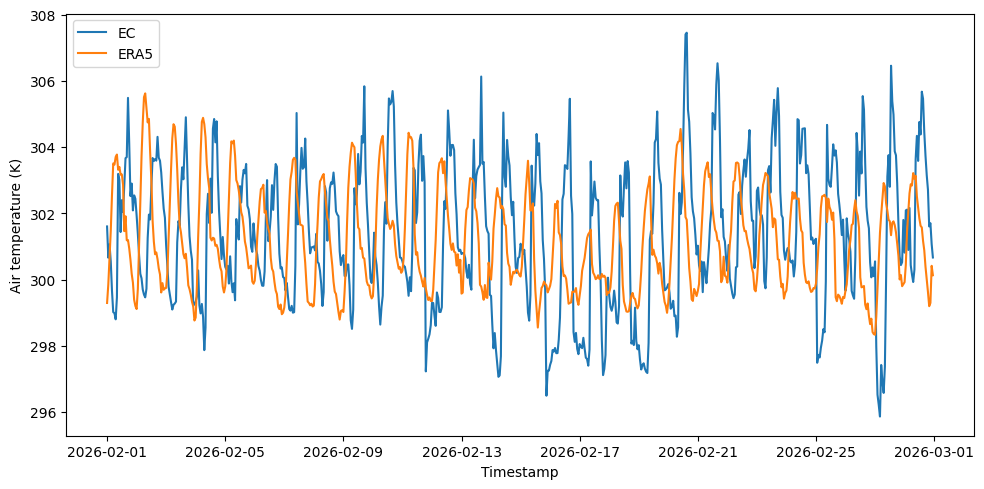

In [94]:

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(df_compare["timestamp"], df_compare["air_temperature_ec"], label="EC")
plt.plot(df_compare["timestamp"], df_compare["air_temperature_era5"], label="ERA5")

plt.xlabel("Timestamp")
plt.ylabel("Air temperature (K)")
plt.legend()
plt.tight_layout()
plt.show()


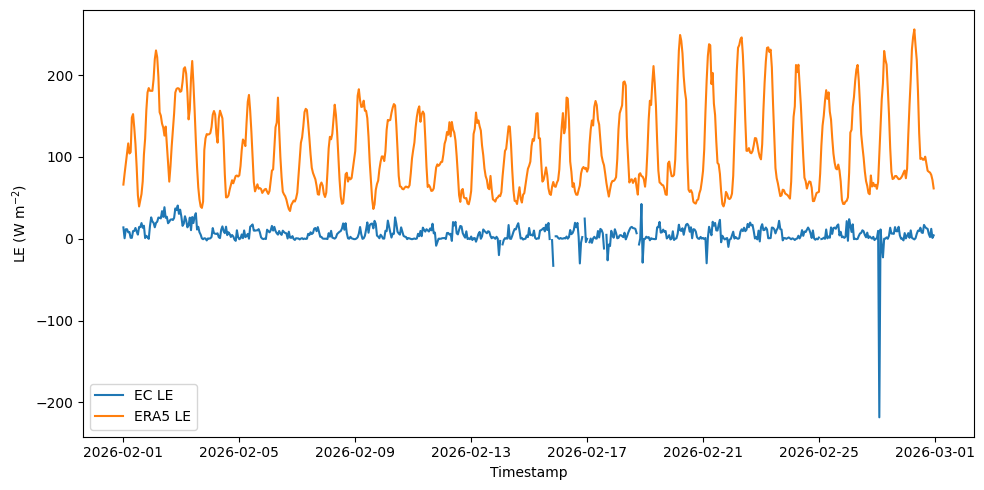

In [95]:

plt.figure(figsize=(10, 5))
plt.plot(df_compare["timestamp"], df_compare["le_ec"], label="EC LE")
plt.plot(df_compare["timestamp"], df_compare["le_era5"], label="ERA5 LE")

plt.xlabel("Timestamp")
plt.ylabel("LE (W m$^{-2}$)")
plt.legend()
plt.tight_layout()
plt.show()


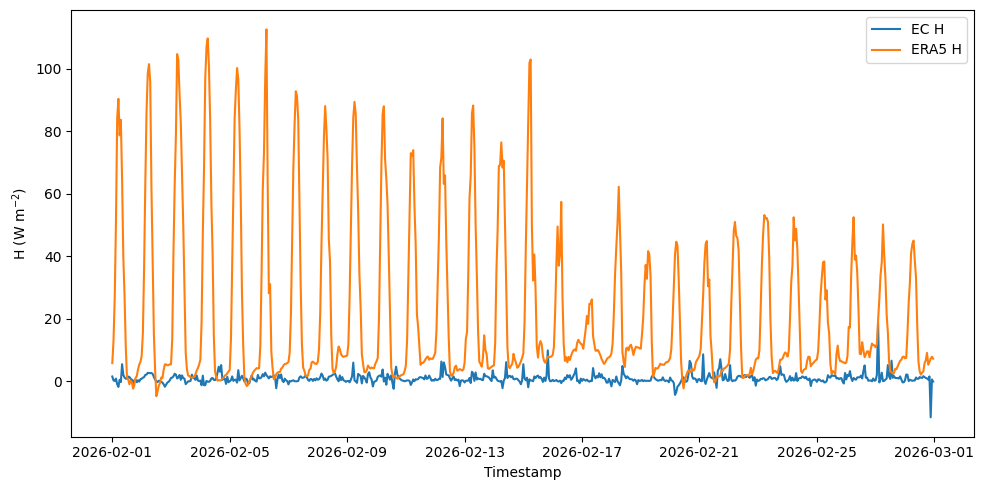

In [96]:

plt.figure(figsize=(10, 5))
plt.plot(df_compare["timestamp"], df_compare["h_ec"], label="EC H")
plt.plot(df_compare["timestamp"], df_compare["h_era5"], label="ERA5 H")

plt.xlabel("Timestamp")
plt.ylabel("H (W m$^{-2}$)")
plt.legend()
plt.tight_layout()
plt.show()
